##Step 2: Data Collection

###Import Necessary Libraries

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgbm
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,roc_auc_score,roc_curve
import warnings
warnings.filterwarnings('ignore')

###Import Dataset

In [ ]:
credit_card_data = pd.read_csv('credit_card_clean.csv')
credit_card_data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,female,university,married,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,female,university,single,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,female,university,single,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,female,university,married,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,male,university,married,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,male,highschool,married,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,male,highschool,single,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,male,university,single,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,male,highschool,married,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


##Step 3: Data Understanding

###Perform Initial Investigation

In [ ]:
credit_card_data.shape

(30000, 25)

In [ ]:
credit_card_data.isna().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_1,0
PAY_2,0
PAY_3,0
PAY_4,0


In [ ]:
credit_card_data.dtypes

,0
ID,int64
LIMIT_BAL,float64
SEX,object
EDUCATION,object
MARRIAGE,object
AGE,int64
PAY_1,int64
PAY_2,int64
PAY_3,int64
PAY_4,int64


In [ ]:
credit_card_data.describe()

,ID,LIMIT_BAL,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


##Step 4: Data Preparation

###Removal of unwanted columns and transformation of data

In [ ]:
del credit_card_data['ID']

In [ ]:
credit_card_data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,female,university,married,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,female,university,single,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,female,university,single,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,female,university,married,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,male,university,married,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,male,highschool,married,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,male,highschool,single,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,male,university,single,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,male,highschool,married,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [ ]:
le = LabelEncoder()
credit_card_data['SEX'] = le.fit_transform(credit_card_data['SEX'])
credit_card_data['EDUCATION'] = le.fit_transform(credit_card_data['EDUCATION'])
credit_card_data['MARRIAGE'] = le.fit_transform(credit_card_data['MARRIAGE'])

In [ ]:
credit_card_data.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,0,3,0,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,0,3,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,0,3,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,0,3,0,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,3,0,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
credit_card_data.dtypes

,0
LIMIT_BAL,float64
SEX,int64
EDUCATION,int64
MARRIAGE,int64
AGE,int64
PAY_1,int64
PAY_2,int64
PAY_3,int64
PAY_4,int64
PAY_5,int64


###separation of input and output features

In [ ]:
X = credit_card_data.drop(labels='DEFAULT',axis=1)
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000.0,0,3,0,24,2,2,-1,-1,-2,...,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0
1,120000.0,0,3,2,26,-1,2,0,0,0,...,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0
2,90000.0,0,3,2,34,0,0,0,0,0,...,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0
3,50000.0,0,3,0,37,0,0,0,0,0,...,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0
4,50000.0,1,3,0,57,-1,0,-1,0,0,...,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,1,0,39,0,0,0,0,0,...,208365.0,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0
29996,150000.0,1,1,2,43,-1,-1,-1,-1,0,...,3502.0,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0
29997,30000.0,1,3,2,37,4,3,2,-1,0,...,2758.0,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0
29998,80000.0,1,1,0,41,1,-1,0,0,0,...,76304.0,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0


In [ ]:
y = credit_card_data['DEFAULT']
y

,DEFAULT
0,1
1,1
2,0
3,0
4,0
...,...
29995,0
29996,0
29997,1
29998,1


##Step 5: Model Building

###Train Test Split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=13, shuffle=True, stratify=y)

###Model Initialization

In [ ]:
adb_classifier = AdaBoostClassifier(n_estimators= 50)

In [ ]:
gb_classifier = GradientBoostingClassifier(n_estimators=50)

In [ ]:
xgb_classifier = xgb.XGBClassifier(n_estimators=50)

In [ ]:
lgbm_classifier = lgbm.LGBMClassifier(n_estimators=50,)

##Step 6: Model Training

In [ ]:
%%time
adb_classifier.fit(X_train,y_train)

CPU times: user 2.92 s, sys: 6.21 ms, total: 2.92 s
Wall time: 2.95 s


AdaBoostClassifier()

In [ ]:
%%time
gb_classifier.fit(X_train,y_train)

CPU times: user 7.71 s, sys: 7.09 ms, total: 7.72 s
Wall time: 8.36 s


GradientBoostingClassifier(n_estimators=50)

In [ ]:
%%time
xgb_classifier.fit(X_train,y_train)

CPU times: user 1.43 s, sys: 4.07 ms, total: 1.43 s
Wall time: 1.28 s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
%%time
lgbm_classifier.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011306 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3260
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639
CPU times: user 418 ms, sys: 5.74 ms, total: 424 ms
Wall time: 469 ms


LGBMClassifier(n_estimators=50)

##Step 7: Model Testing

###Training Data Prediction

In [ ]:
y_pred_adb_train = adb_classifier.predict(X_train)

In [ ]:
y_pred_gb_train = gb_classifier.predict(X_train)

In [ ]:
y_pred_xgb_train = xgb_classifier.predict(X_train)

In [ ]:
y_pred_lgbm_train = lgbm_classifier.predict(X_train)

###Test Data Prediction

In [ ]:
y_pred_adb_test =adb_classifier.predict(X_test)

In [ ]:
y_pred_gb_test = gb_classifier.predict(X_test)

In [ ]:
y_pred_xgb_test = xgb_classifier.predict(X_test)

In [ ]:
y_pred_lgbm_test = lgbm_classifier.predict(X_test)

##Step 8: Model Evaluation

###Training data Evaluation

### 1.Adaboost

In [ ]:
print('accuracy score:',round(accuracy_score(y_train,y_pred_adb_train),4))
print('precision score:',round(precision_score(y_train,y_pred_adb_train),4))
print('recall score:',round(recall_score(y_train,y_pred_adb_train),4))
print('confusion matrix:\n',confusion_matrix(y_train,y_pred_adb_train))

accuracy score: 0.819
precision score: 0.6918
recall score: 0.3277
confusion matrix:
 [[17916   775]
 [ 3569  1740]]


auc score 0.7770098834210472


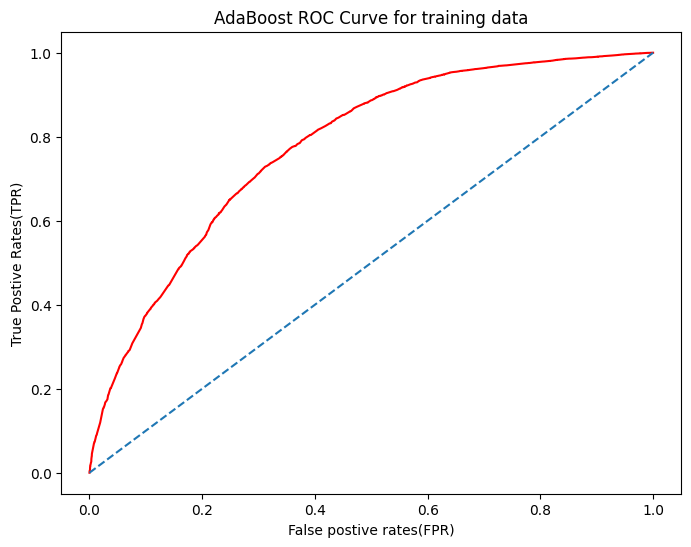

In [ ]:
y_prob = adb_classifier.predict_proba(X_train)[:,0]
fpr,tpr,threshold = roc_curve(y_train,y_prob,pos_label=0)
print('auc score',roc_auc_score((y_train==0).astype(int),y_prob))
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1],linestyle='--')
plt.title('AdaBoost ROC Curve for training data')
plt.xlabel('False postive rates(FPR)')
plt.ylabel('True Postive Rates(TPR)')
plt.show()

###2.Gradient Boosting

In [ ]:
print('accuracy score:',round(accuracy_score(y_train,y_pred_gb_train),4))
print('precision score:',round(precision_score(y_train,y_pred_gb_train),4))
print('recall score:',round(recall_score(y_train,y_pred_gb_train),4))
print('confusion matrix:\n',confusion_matrix(y_train,y_pred_gb_train))

accuracy score: 0.8259
precision score: 0.6986
recall score: 0.3746
confusion matrix:
 [[17833   858]
 [ 3320  1989]]


auc score 0.7953235838663708


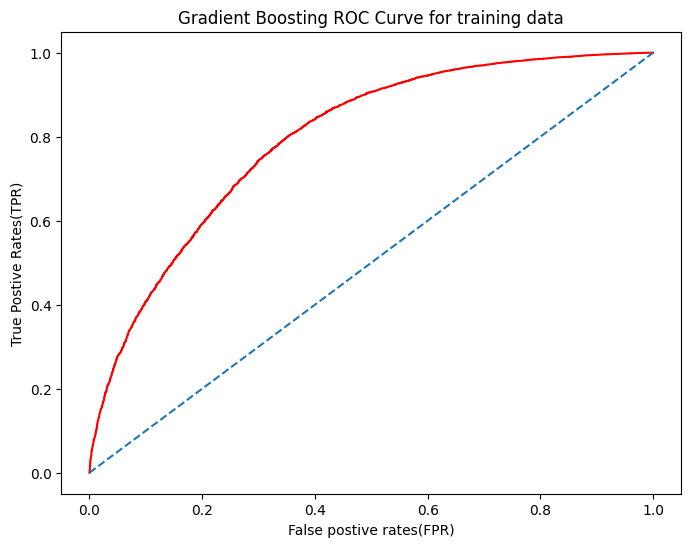

In [ ]:
y_prob = gb_classifier.predict_proba(X_train)[:,0]
fpr,tpr,threshold = roc_curve(y_train,y_prob,pos_label=0)
print('auc score',roc_auc_score((y_train==0).astype(int),y_prob))
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1],linestyle='--')
plt.title('Gradient Boosting ROC Curve for training data')
plt.xlabel('False postive rates(FPR)')
plt.ylabel('True Postive Rates(TPR)')
plt.show()

###3.Xtreme Gradient Boosting

In [ ]:
print('accuracy score:',round(accuracy_score(y_train,y_pred_xgb_train),4))
print('precision score:',round(precision_score(y_train,y_pred_xgb_train),4))
print('recall score:',round(recall_score(y_train,y_pred_xgb_train),4))
print('confusion matrix:\n',confusion_matrix(y_train,y_pred_xgb_train))

accuracy score: 0.8592
precision score: 0.8031
recall score: 0.4818
confusion matrix:
 [[18064   627]
 [ 2751  2558]]


auc score 0.8957281479098179


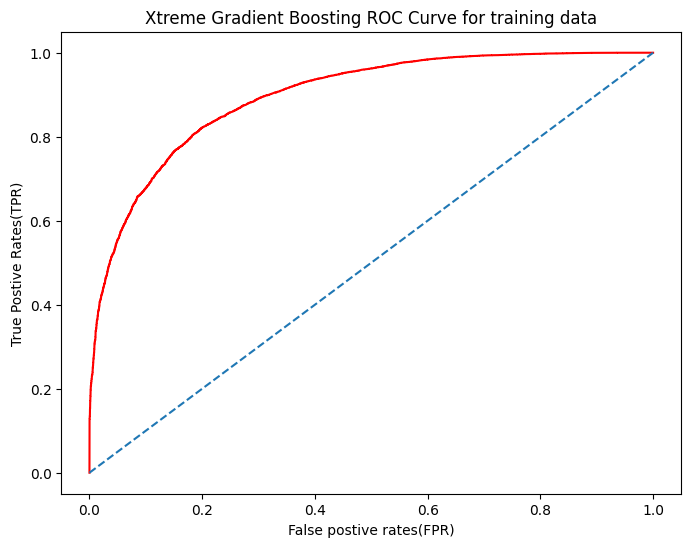

In [ ]:
y_prob = xgb_classifier.predict_proba(X_train)[:,0]
fpr,tpr,threshold = roc_curve(y_train,y_prob,pos_label=0)
print('auc score',roc_auc_score((y_train==0).astype(int),y_prob))
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1],linestyle='--')
plt.title('Xtreme Gradient Boosting ROC Curve for training data')
plt.xlabel('False postive rates(FPR)')
plt.ylabel('True Postive Rates(TPR)')
plt.show()

###4.Light Gradient Boosting

In [ ]:
print('accuracy score:',round(accuracy_score(y_train,y_pred_lgbm_train),4))
print('precision score:',round(precision_score(y_train,y_pred_lgbm_train),4))
print('recall score:',round(recall_score(y_train,y_pred_lgbm_train),4))
print('confusion matrix:\n',confusion_matrix(y_train,y_pred_lgbm_train))

accuracy score: 0.8334
precision score: 0.7214
recall score: 0.402
confusion matrix:
 [[17867   824]
 [ 3175  2134]]


auc score 0.8495742826861563


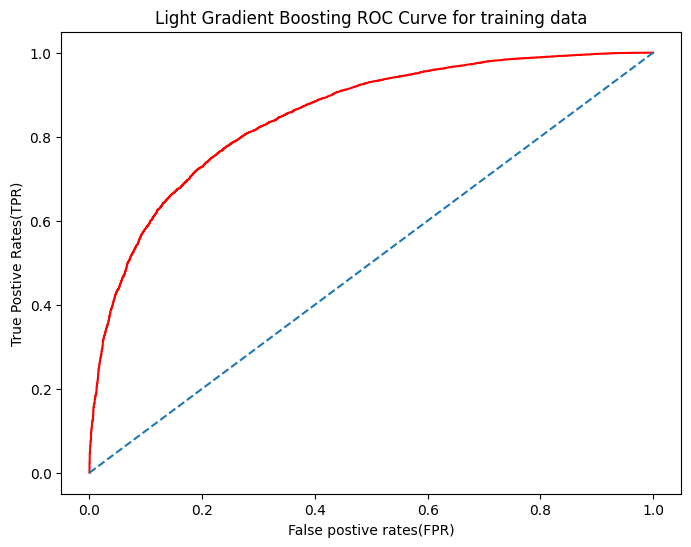

In [ ]:
y_prob = lgbm_classifier.predict_proba(X_train)[:,0]
fpr,tpr,threshold = roc_curve(y_train,y_prob,pos_label=0)
print('auc score',roc_auc_score((y_train==0).astype(int),y_prob))
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1],linestyle='--')
plt.title('Light Gradient Boosting ROC Curve for training data')
plt.xlabel('False postive rates(FPR)')
plt.ylabel('True Postive Rates(TPR)')
plt.show()

###Test Data Evaluation

####1.AdaBoost

In [ ]:
print('accuracy score:',round(accuracy_score(y_test,y_pred_adb_test),4))
print('precision score:',round(precision_score(y_test,y_pred_adb_test),4))
print('recall score:',round(recall_score(y_test,y_pred_adb_test),4))
print('confusion matrix:\n',confusion_matrix(y_test,y_pred_adb_test))

accuracy score: 0.8137
precision score: 0.6786
recall score: 0.2992
confusion matrix:
 [[4485  188]
 [ 930  397]]


auc score 0.7611794801252881


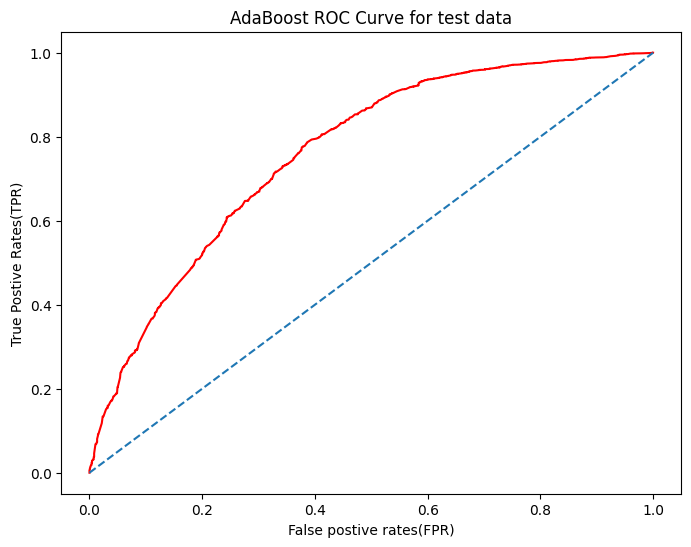

In [ ]:
y_prob = adb_classifier.predict_proba(X_test)[:,0]
fpr,tpr,threshold = roc_curve(y_test,y_prob,pos_label=0)
print('auc score',roc_auc_score((y_test==0).astype(int),y_prob))
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1],linestyle='--')
plt.title('AdaBoost ROC Curve for test data')
plt.xlabel('False postive rates(FPR)')
plt.ylabel('True Postive Rates(TPR)')
plt.show()

####2.Gradient Boosting

In [ ]:
print('accuracy score:',round(accuracy_score(y_test,y_pred_gb_test),4))
print('precision score:',round(precision_score(y_test,y_pred_gb_test),4))
print('recall score:',round(recall_score(y_test,y_pred_gb_test),4))
print('confusion matrix:\n',confusion_matrix(y_test,y_pred_gb_test))

accuracy score: 0.8177
precision score: 0.6795
recall score: 0.3323
confusion matrix:
 [[4465  208]
 [ 886  441]]


auc score 0.7691697934114929


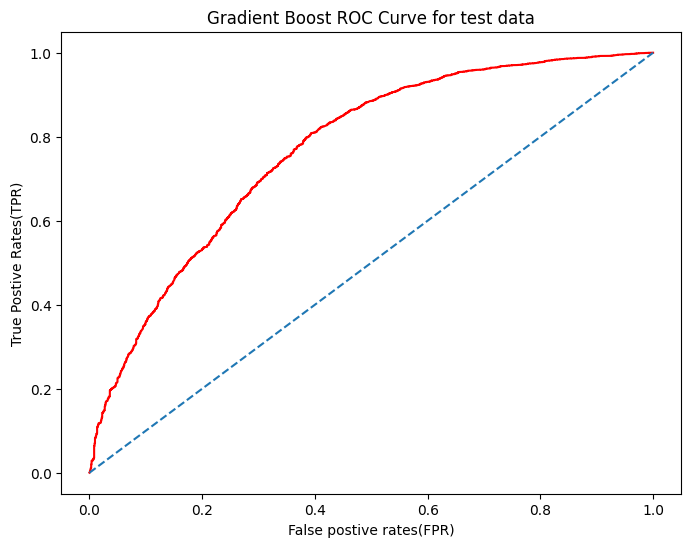

In [ ]:
y_prob = gb_classifier.predict_proba(X_test)[:,0]
fpr,tpr,threshold = roc_curve(y_test,y_prob,pos_label=0)
print('auc score',roc_auc_score((y_test==0).astype(int),y_prob))
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1],linestyle='--')
plt.title('Gradient Boost ROC Curve for test data')
plt.xlabel('False postive rates(FPR)')
plt.ylabel('True Postive Rates(TPR)')
plt.show()

####3.XTreme Gradient Boosting

In [ ]:
print('accuracy score:',round(accuracy_score(y_test,y_pred_xgb_test),4))
print('precision score:',round(precision_score(y_test,y_pred_xgb_test),4))
print('recall score:',round(recall_score(y_test,y_pred_xgb_test),4))
print('confusion matrix:\n',confusion_matrix(y_test,y_pred_xgb_test))

accuracy score: 0.811
precision score: 0.6306
recall score: 0.3512
confusion matrix:
 [[4400  273]
 [ 861  466]]


auc score 0.7566466341056246


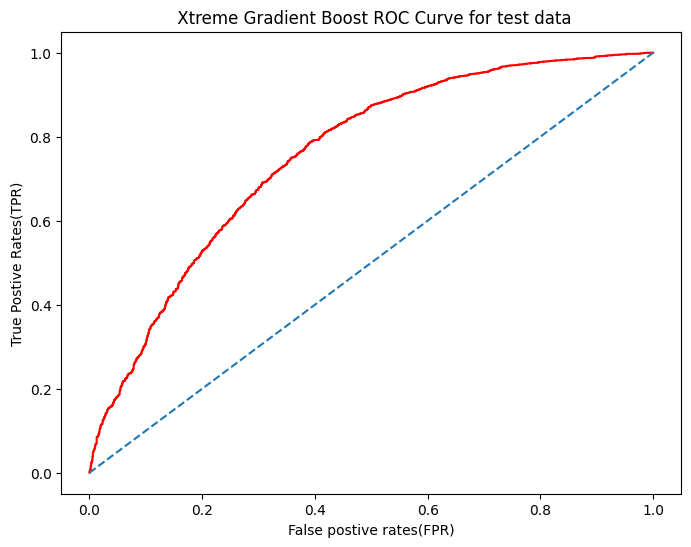

In [ ]:
y_prob = xgb_classifier.predict_proba(X_test)[:,0]
fpr,tpr,threshold = roc_curve(y_test,y_prob,pos_label=0)
print('auc score',roc_auc_score((y_test==0).astype(int),y_prob))
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1],linestyle='--')
plt.title(' Xtreme Gradient Boost ROC Curve for test data')
plt.xlabel('False postive rates(FPR)')
plt.ylabel('True Postive Rates(TPR)')
plt.show()

####4.Light Gradient Boosting

In [ ]:
print('accuracy score:',round(accuracy_score(y_test,y_pred_lgbm_test),4))
print('precision score:',round(precision_score(y_test,y_pred_lgbm_test),4))
print('recall score:',round(recall_score(y_test,y_pred_lgbm_test),4))
print('confusion matrix:\n',confusion_matrix(y_test,y_pred_lgbm_test))

accuracy score: 0.8157
precision score: 0.6647
recall score: 0.3361
confusion matrix:
 [[4448  225]
 [ 881  446]]


auc score 0.7690357843024214


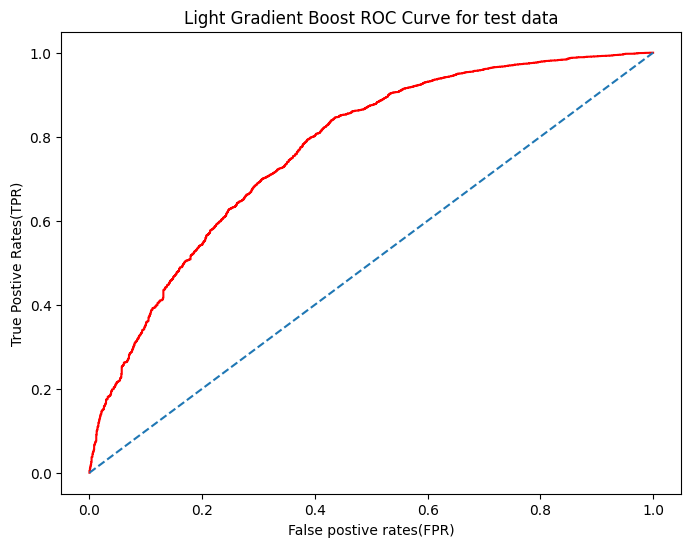

In [ ]:
y_prob = lgbm_classifier.predict_proba(X_test)[:,0]
fpr,tpr,threshold = roc_curve(y_test,y_prob,pos_label=0)
print('auc score',roc_auc_score((y_test==0).astype(int),y_prob))
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1],linestyle='--')
plt.title('Light Gradient Boost ROC Curve for test data')
plt.xlabel('False postive rates(FPR)')
plt.ylabel('True Postive Rates(TPR)')
plt.show()